# CREATING THE FINAL DATASET 

## 1.IMPORTING THE RAW DATASET

In [1]:
import pandas as pd 

In [2]:
dataset=pd.read_csv('dataset.csv')

In [3]:
dataset.head()

,TransactionID,UserID,Amount,Timestamp,MerchantCategory,TransactionType,DeviceID,IPAddress,Latitude,Longitude,AvgTransactionAmount,TransactionFrequency,UnusualLocation,UnusualAmount,NewDevice,FailedAttempts,FraudFlag,PhoneNumber,BankName
0,842835309389,b0b99baa-1fd2-41e5-ac94-37aa0ec862f9,8589.00,2024-01-22 03:59:58,Electronics,P2M,42296fa1-8d7a-478c-a8c9-590b9d14cdb9,75.122.84.213,23.354478,-40.536076,670.31,5/day,False,True,False,2,True,2798604680,Bank of Baroda
1,592863054785,0cc467c5-8b71-4ba4-9c75-4a9e2bec2c8c,9090.54,2024-07-01 13:43:33,Electronics,P2M,e566b8a8-17c3-4372-9e07-e4c4eb3113b7,16.110.81.53,-62.956912,-102.511919,7265.96,3/day,False,True,False,2,False,3614149152,ICICI Bank
2,373481869464,f7de03ee-b7f5-4568-8ba2-e889bced4d88,8814.41,2024-04-02 05:23:39,Electronics,P2P,897d0824-bc4f-4ee7-9bfb-c8eea31b2ca2,6.47.215.37,-13.112830,-18.978059,8750.89,3/day,True,False,True,3,False,912661191911,ICICI Bank
3,285572156436,456b3f39-e9cc-429f-8568-125612c12987,3971.25,2024-06-14 16:13:43,Restaurants,P2P,a4d2f5ef-19c7-4baa-b3ea-b04069d65021,214.166.195.254,-23.898771,81.760634,8348.14,1/day,True,True,False,4,False,916358088125,State Bank of India
4,874207772966,7b4b734d-f0c5-4dce-8b9c-0b2e226abc86,4376.74,2024-07-16 03:22:40,Groceries,P2M,8aee664a-fb51-4e74-98a1-cf632a02cd27,151.99.121.13,11.383999,12.669192,1719.74,1/day,True,True,False,0,False,5132838721,ICICI Bank


## 2.ANALYSING THE DATASET

In [4]:
dataset.shape

(10000, 19)

In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionID         10000 non-null  int64  
 1   UserID                10000 non-null  object 
 2   Amount                10000 non-null  float64
 3   Timestamp             10000 non-null  object 
 4   MerchantCategory      10000 non-null  object 
 5   TransactionType       10000 non-null  object 
 6   DeviceID              10000 non-null  object 
 7   IPAddress             10000 non-null  object 
 8   Latitude              10000 non-null  float64
 9   Longitude             10000 non-null  float64
 10  AvgTransactionAmount  10000 non-null  float64
 11  TransactionFrequency  10000 non-null  object 
 12  UnusualLocation       10000 non-null  bool   
 13  UnusualAmount         10000 non-null  bool   
 14  NewDevice             10000 non-null  bool   
 15  FailedAttempts      

In [6]:
fraud= dataset[dataset['FraudFlag']==1]
valid= dataset[dataset['FraudFlag']==0]

In [7]:
print("Number of fraud data :", len(fraud))
print("Number of valid data :", len(valid))

Number of fraud data : 965
Number of valid data : 9035


<Axes: xlabel='FraudFlag', ylabel='count'>

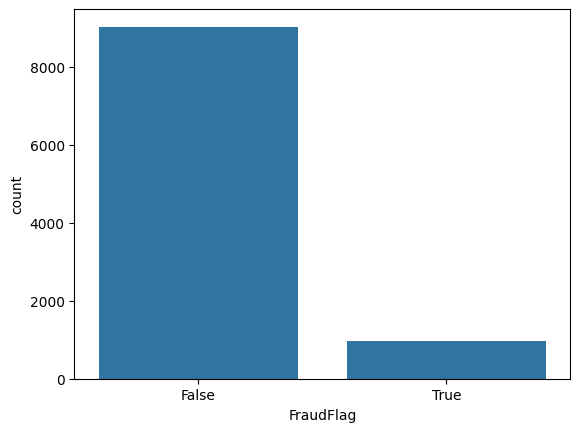

In [8]:
import seaborn as sns 
sns.countplot(x = 'FraudFlag', data = dataset)

## 3. BALANCING THE DATASET USING "Over-SAMPLING"

In [9]:
dataset.shape

(10000, 19)

In [10]:
# valid=valid.sample(len(fraud))

In [11]:
# fraud= dataset[dataset['FraudFlag']==1]
# valid= dataset[dataset['FraudFlag']==0]
# print("Number of fraud data :", len(fraud))
# print("Number of valid data :", len(valid))

In [12]:
# fraud_over= fraud.sample(len(valid) , repla
# ce=True)
# print(len(fraud_over))

In [13]:
# dataset= pd.concat([valid, fraud_over],axis=0)

In [14]:
# dataset= dataset.sort_index()

In [15]:
# dataset.reset_index(drop=True, inplace=True)

In [16]:
# fraud= dataset[dataset['FraudFlag']==1]
# valid= dataset[dataset['FraudFlag']==0]
# print("Number of fraud data :", len(fraud))
# print("Number of valid data :", len(valid))

In [17]:
# import seaborn as sns 
# sns.countplot(x = 'FraudFlag', data = dataset)

## 4. CALCULATING THE TRANSACTION TIME, DAY, MONTH, AND YEAR

In [18]:
dataset['Timestamp'] = pd.to_datetime(dataset['Timestamp'])

In [19]:
dataset.insert(2, 'trans_hour', dataset['Timestamp'].dt.hour)
dataset.insert(3, 'trans_day', dataset['Timestamp'].dt.day)
dataset.insert(4, 'trans_month', dataset['Timestamp'].dt.month)
dataset.insert(5, 'trans_year', dataset['Timestamp'].dt.year)

In [20]:
dataset.head()

,TransactionID,UserID,trans_hour,trans_day,trans_month,trans_year,Amount,Timestamp,MerchantCategory,TransactionType,...,Longitude,AvgTransactionAmount,TransactionFrequency,UnusualLocation,UnusualAmount,NewDevice,FailedAttempts,FraudFlag,PhoneNumber,BankName
0,842835309389,b0b99baa-1fd2-41e5-ac94-37aa0ec862f9,3,22,1,2024,8589.00,2024-01-22 03:59:58,Electronics,P2M,...,-40.536076,670.31,5/day,False,True,False,2,True,2798604680,Bank of Baroda
1,592863054785,0cc467c5-8b71-4ba4-9c75-4a9e2bec2c8c,13,1,7,2024,9090.54,2024-07-01 13:43:33,Electronics,P2M,...,-102.511919,7265.96,3/day,False,True,False,2,False,3614149152,ICICI Bank
2,373481869464,f7de03ee-b7f5-4568-8ba2-e889bced4d88,5,2,4,2024,8814.41,2024-04-02 05:23:39,Electronics,P2P,...,-18.978059,8750.89,3/day,True,False,True,3,False,912661191911,ICICI Bank
3,285572156436,456b3f39-e9cc-429f-8568-125612c12987,16,14,6,2024,3971.25,2024-06-14 16:13:43,Restaurants,P2P,...,81.760634,8348.14,1/day,True,True,False,4,False,916358088125,State Bank of India
4,874207772966,7b4b734d-f0c5-4dce-8b9c-0b2e226abc86,3,16,7,2024,4376.74,2024-07-16 03:22:40,Groceries,P2M,...,12.669192,1719.74,1/day,True,True,False,0,False,5132838721,ICICI Bank


## 5.EXTRACTING NUMERIC FROM TransactionFrequency

In [21]:
dataset['TransactionFrequency'] = dataset['TransactionFrequency'].str.extract(r'(\d+)').astype(int)

In [22]:
if 'TransactionFrequency_Numeric' in dataset.columns:
    del dataset['TransactionFrequency_Numeric']
dataset.head()

,TransactionID,UserID,trans_hour,trans_day,trans_month,trans_year,Amount,Timestamp,MerchantCategory,TransactionType,...,Longitude,AvgTransactionAmount,TransactionFrequency,UnusualLocation,UnusualAmount,NewDevice,FailedAttempts,FraudFlag,PhoneNumber,BankName
0,842835309389,b0b99baa-1fd2-41e5-ac94-37aa0ec862f9,3,22,1,2024,8589.00,2024-01-22 03:59:58,Electronics,P2M,...,-40.536076,670.31,5,False,True,False,2,True,2798604680,Bank of Baroda
1,592863054785,0cc467c5-8b71-4ba4-9c75-4a9e2bec2c8c,13,1,7,2024,9090.54,2024-07-01 13:43:33,Electronics,P2M,...,-102.511919,7265.96,3,False,True,False,2,False,3614149152,ICICI Bank
2,373481869464,f7de03ee-b7f5-4568-8ba2-e889bced4d88,5,2,4,2024,8814.41,2024-04-02 05:23:39,Electronics,P2P,...,-18.978059,8750.89,3,True,False,True,3,False,912661191911,ICICI Bank
3,285572156436,456b3f39-e9cc-429f-8568-125612c12987,16,14,6,2024,3971.25,2024-06-14 16:13:43,Restaurants,P2P,...,81.760634,8348.14,1,True,True,False,4,False,916358088125,State Bank of India
4,874207772966,7b4b734d-f0c5-4dce-8b9c-0b2e226abc86,3,16,7,2024,4376.74,2024-07-16 03:22:40,Groceries,P2M,...,12.669192,1719.74,1,True,True,False,0,False,5132838721,ICICI Bank


## 6.DELETING THE REDUNDANT FEATURES

In [23]:
if 'Timestamp' in dataset.columns:
    del dataset['Timestamp']

In [24]:
if 'trans_year' in dataset.columns:
    del dataset['trans_year']

In [25]:
if 'TransactionID' in dataset.columns:
    del dataset['TransactionID']
if 'UserID' in dataset.columns:
    del dataset['UserID']
if 'DeviceID' in dataset.columns:
    del dataset['DeviceID']
if 'IPAddress' in dataset.columns:
    del dataset['IPAddress']
if 'PhoneNumber' in dataset.columns:
    del dataset['PhoneNumber']
if 'Latitude' in dataset.columns:
    del dataset['Latitude']
if 'Longitude' in dataset.columns:
    del dataset['Longitude']

In [26]:
dataset['Amount_to_Avg_Ratio'] = dataset['Amount'] / dataset['AvgTransactionAmount']

In [27]:
dataset.head()

,trans_hour,trans_day,trans_month,Amount,MerchantCategory,TransactionType,AvgTransactionAmount,TransactionFrequency,UnusualLocation,UnusualAmount,NewDevice,FailedAttempts,FraudFlag,BankName,Amount_to_Avg_Ratio
0,3,22,1,8589.00,Electronics,P2M,670.31,5,False,True,False,2,True,Bank of Baroda,12.813474
1,13,1,7,9090.54,Electronics,P2M,7265.96,3,False,True,False,2,False,ICICI Bank,1.251113
2,5,2,4,8814.41,Electronics,P2P,8750.89,3,True,False,True,3,False,ICICI Bank,1.007259
3,16,14,6,3971.25,Restaurants,P2P,8348.14,1,True,True,False,4,False,State Bank of India,0.475705
4,3,16,7,4376.74,Groceries,P2M,1719.74,1,True,True,False,0,False,ICICI Bank,2.545001


## 7.USING LABEL ENCODER

In [28]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

In [29]:
dataset['MerchantCategory'] = labelencoder.fit_transform(dataset['MerchantCategory'])
dataset['TransactionType'] = labelencoder.fit_transform(dataset['TransactionType'])
dataset['AvgTransactionAmount'] = labelencoder.fit_transform(dataset['AvgTransactionAmount'])
dataset['AvgTransactionAmount'] = labelencoder.inverse_transform(dataset['AvgTransactionAmount'])
dataset['UnusualLocation'] = labelencoder.fit_transform(dataset['UnusualLocation'])
dataset['UnusualAmount'] = labelencoder.fit_transform(dataset['UnusualAmount'])
dataset['NewDevice'] = labelencoder.fit_transform(dataset['NewDevice'])
dataset['FraudFlag'] = labelencoder.fit_transform(dataset['FraudFlag'])
dataset['BankName'] = labelencoder.fit_transform(dataset['BankName'])

In [30]:
dataset.head()

,trans_hour,trans_day,trans_month,Amount,MerchantCategory,TransactionType,AvgTransactionAmount,TransactionFrequency,UnusualLocation,UnusualAmount,NewDevice,FailedAttempts,FraudFlag,BankName,Amount_to_Avg_Ratio
0,3,22,1,8589.00,1,0,670.31,5,0,1,0,2,1,1,12.813474
1,13,1,7,9090.54,1,0,7265.96,3,0,1,0,2,0,3,1.251113
2,5,2,4,8814.41,1,1,8750.89,3,1,0,1,3,0,3,1.007259
3,16,14,6,3971.25,4,1,8348.14,1,1,1,0,4,0,5,0.475705
4,3,16,7,4376.74,3,0,1719.74,1,1,1,0,0,0,3,2.545001


## SAVING THE FINAL DATASET

In [31]:
# Move fraudflag column to last
cols = [col for col in dataset.columns if col != 'FraudFlag'] + ['FraudFlag']

dataset = dataset[cols]

In [32]:
import os.path

In [33]:
if os.path.isfile('clean_dataset.csv') is False:
    dataset.to_csv('clean_dataset.csv')

## 8.ANALYSING THE UPDATED DATASET

In [34]:
dataset.shape

(10000, 15)

In [35]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   trans_hour            10000 non-null  int32  
 1   trans_day             10000 non-null  int32  
 2   trans_month           10000 non-null  int32  
 3   Amount                10000 non-null  float64
 4   MerchantCategory      10000 non-null  int64  
 5   TransactionType       10000 non-null  int64  
 6   AvgTransactionAmount  10000 non-null  float64
 7   TransactionFrequency  10000 non-null  int64  
 8   UnusualLocation       10000 non-null  int64  
 9   UnusualAmount         10000 non-null  int64  
 10  NewDevice             10000 non-null  int64  
 11  FailedAttempts        10000 non-null  int64  
 12  BankName              10000 non-null  int64  
 13  Amount_to_Avg_Ratio   10000 non-null  float64
 14  FraudFlag             10000 non-null  int64  
dtypes: float64(3), int32

In [36]:
fraud = dataset[dataset['FraudFlag'] == 1]
valid = dataset[dataset['FraudFlag'] == 0]

In [37]:
print("Number of fraud data :", len(fraud))
print("Number of valid data :", len(valid))

Number of fraud data : 965
Number of valid data : 9035


<Axes: xlabel='FraudFlag', ylabel='count'>

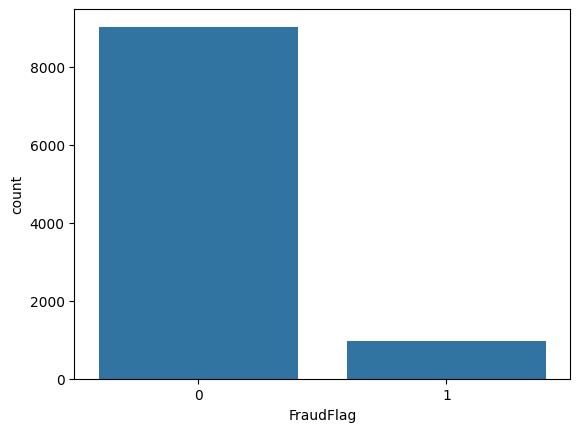

In [38]:
sns.countplot(x = 'FraudFlag', data = dataset)

In [39]:
dataset.nunique()

trans_hour                 24
trans_day                  31
trans_month                 7
Amount                   9957
MerchantCategory            7
TransactionType             2
AvgTransactionAmount     9949
TransactionFrequency        3
UnusualLocation             2
UnusualAmount               2
NewDevice                   2
FailedAttempts              5
BankName                    6
Amount_to_Avg_Ratio     10000
FraudFlag                   2
dtype: int64

In [40]:
dataset.head()

,trans_hour,trans_day,trans_month,Amount,MerchantCategory,TransactionType,AvgTransactionAmount,TransactionFrequency,UnusualLocation,UnusualAmount,NewDevice,FailedAttempts,BankName,Amount_to_Avg_Ratio,FraudFlag
0,3,22,1,8589.00,1,0,670.31,5,0,1,0,2,1,12.813474,1
1,13,1,7,9090.54,1,0,7265.96,3,0,1,0,2,3,1.251113,0
2,5,2,4,8814.41,1,1,8750.89,3,1,0,1,3,3,1.007259,0
3,16,14,6,3971.25,4,1,8348.14,1,1,1,0,4,5,0.475705,0
4,3,16,7,4376.74,3,0,1719.74,1,1,1,0,0,3,2.545001,0
